# Steam Games — EDA

## 0. Setup & Load Data

In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

ds = pd.read_csv("../data/processed/games_cleaned.csv")

## 1. Data Overview

In [16]:
print(ds.shape)
print(ds.dtypes)
print(ds.columns.tolist())
ds.isnull().sum().sort_values(ascending=False)

(122611, 20)
AppID                        int64
name                           str
release_date                   str
required_age                 int64
price                      float64
dlc_count                    int64
recommendations              int64
developers                     str
publishers                     str
genres                         str
positive                     int64
negative                     int64
owners_mid                 float64
median_playtime_forever      int64
peak_ccu                     int64
tags                           str
platform_count               int64
release_year                 int64
release_month                int64
review_score               float64
dtype: object
['AppID', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'recommendations', 'developers', 'publishers', 'genres', 'positive', 'negative', 'owners_mid', 'median_playtime_forever', 'peak_ccu', 'tags', 'platform_count', 'release_year', 'release_month', 'review_

review_score               39662
name                           1
release_month                  0
release_year                   0
platform_count                 0
tags                           0
peak_ccu                       0
median_playtime_forever        0
owners_mid                     0
negative                       0
AppID                          0
genres                         0
publishers                     0
developers                     0
recommendations                0
dlc_count                      0
price                          0
required_age                   0
release_date                   0
positive                       0
dtype: int64

### one ghost entry with empty name and all zero values

In [20]:
ds = ds.dropna(subset=["name"])

## 2. Commercial Success Analysis

### 2a. Price vs Owners

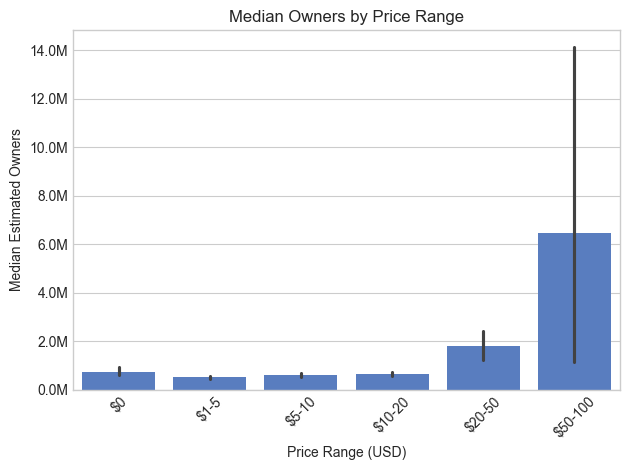

In [37]:
filtered = ds[(ds["price"] <= 100) & (ds["owners_mid"] >= 50000)].copy()
bins = [0, 1, 5, 10, 20, 50, 100]
labels = ['$0', '$1-5', '$5-10', '$10-20', '$20-50', '$50-100']
filtered["price_bucket"] = pd.cut(filtered["price"], bins=bins, labels=labels, include_lowest=True)

plt.title("Median Owners by Price Range")
sns.barplot(x="price_bucket", y="owners_mid", data=filtered)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')) # format the median owners
plt.xlabel("Price Range (USD)")
plt.ylabel("Median Estimated Owners")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Among commercially successful games (50k+ owners), premium priced games 
($20+) achieve higher average ownership than cheap games. Price alone 
doesn't hurt sales — game quality and marketing matter more.
The flat $0-$20 range suggests the budget market is saturated with 
similar-performing titles.

### 2b. Review Score vs Owners 

### 2c. Playtime vs Owners

### 2d. Platform Count vs Owners

### 2e. Genre vs Owners

## 3. Player Retention Analysis

### 3a. Which genres have highest median playtime?

### 3b. Playtime vs Review Score

## 4. Release Timing Analysis

### 4a. Games released per year (growth trend)

### 4b. Review score by release month

### 4c. Owners by release year

## 5. Price Analysis

### 5a. Price distribution

### 5b. Price by genre

### 5c. Price sweet spot — rating vs sales

## 6. Genre Trends

### 6a. Top genres by volume

### 6b. Genre growth over time

### 6c. Genre vs commercial success

## 7. Key Findings Summary

In [8]:
print(ds["price"].value_counts().sort_index().tail(20))
print(ds[ds["price"] > 100]["price"].describe())

price
99.95       1
99.99      24
109.99      1
112.49      1
119.99      3
124.99      1
127.49      1
129.99      5
139.99      1
149.99      6
160.00      1
175.99      1
199.20      1
199.99    280
269.99      1
299.90      1
299.99      1
500.00      1
999.00      1
999.98      2
Name: count, dtype: int64
count    309.000000
mean     205.262265
std       82.882273
min      109.990000
25%      199.990000
50%      199.990000
75%      199.990000
max      999.980000
Name: price, dtype: float64
